In [2]:
import xarray as xr
import fsspec
import zarr

import numpy as np
import pandas as pd

import csv
import numpy as np
import matplotlib.pyplot as plt

import random
import os
from tqdm import tqdm
import gc
from pathlib import Path

In [5]:
ds = xr.open_dataset('./data/dataset_greece.nc')

In [4]:
ds.variables

Frozen({'burned_areas': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  Rasterized burned polygons
    title:      EFFIS (https://effis.jrc.ec.europa.eu/) burned areas burned a..., 'ignition_points': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  Rasterized ignition points
    title:      Ignition points burned as raster (value 1) on the map calcula..., 'ndvi': <xarray.Variable (time: 4560, y: 983, x: 1253)> Size: 22GB
[5616547440 values with dtype=float32]
Attributes:
    units:      unitless
    long_name:  16-day NDVI
    title:      Normalized Difference Vegetation Index - MODIS/Terra Vegetati..., 'number_of_fires': <xarray.Variable (time: 4560)> Size: 9kB
[4560 values with dtype=int16]
Attributes:
    units:      unitless
    long_name:  Daily number of fires
    title:      Da

In [6]:
ds

<xarray.Dataset> Size: 832GB
Dimensions:             (time: 4560, y: 983, x: 1253)
Coordinates:
  * time                (time) datetime64[ns] 36kB 2009-03-06T10:00:00 ... 20...
  * y                   (y) float64 8kB 42.3 42.29 42.28 ... 34.32 34.31 34.3
  * x                   (x) float64 10kB 18.7 18.71 18.72 ... 28.88 28.89 28.9
    band                int64 8B ...
    spatial_ref         int64 8B ...
Data variables: (12/90)
    burned_areas        (time, y, x) float32 22GB ...
    ignition_points     (time, y, x) float32 22GB ...
    ndvi                (time, y, x) float32 22GB ...
    number_of_fires     (time) int16 9kB ...
    evi                 (time, y, x) float32 22GB ...
    et                  (time, y, x) float32 22GB ...
    ...                  ...
    POP_DENS_2016       (y, x) float32 5MB ...
    POP_DENS_2017       (y, x) float32 5MB ...
    POP_DENS_2018       (y, x) float32 5MB ...
    POP_DENS_2019       (y, x) float32 5MB ...
    POP_DENS_2020       (y, x) float32 5MB ...
    POP_DENS_2021       (y, x) float32 5MB ...
Attributes:
    temporal_extent:   (2009-03-06, 2021-08-29)
    spatial_extent:    (18.7, 28.9, 34.3, 42.3)
    crs:               EPSG:4326
    license:           Creative Commons Attribution v4
    creators:          Ioannis Prapas, Spyros Kondylatos, Ioannis Papoutsis
    contact_person:    Ioannis Prapas <iprapas (at) noa.gr>
    citation:          Ioannis Prapas, Spyros Kondylatos, & Ioannis Papoutsis...
    acknowledgements:  This work has received funding from the European Union...
    title:             FireCube: A Daily Datacube for the Modeling and Analys...

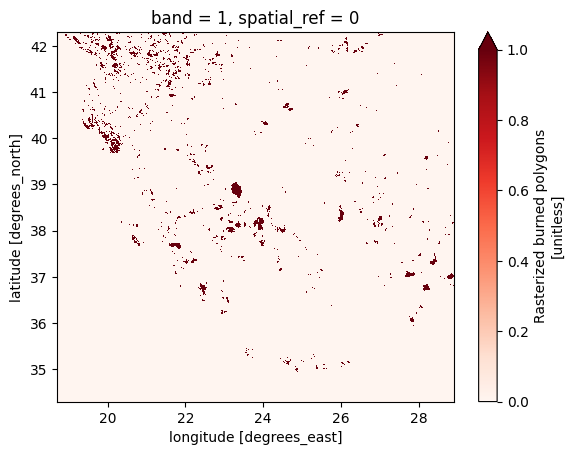

In [22]:
# 变量burned_areas 燃烧区域
# 查看历史上所有发生过火灾的区域叠加图
ds['burned_areas'].sum(dim='time').plot(cmap='Reds',vmin=0,vmax=1)

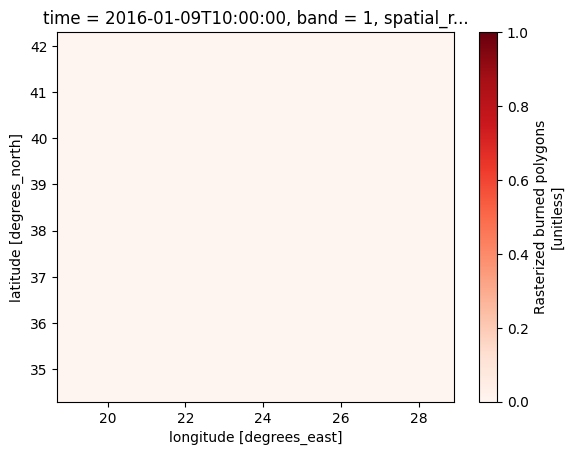

In [18]:
# 查看某一天的火灾区域图
ds['burned_areas'].isel(time=2500).plot(cmap='Reds', vmin=0, vmax=1)

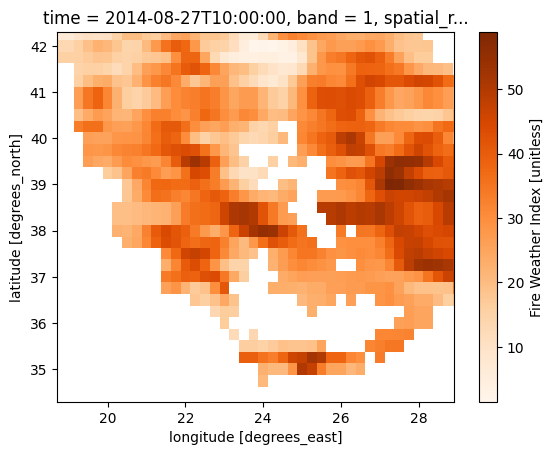

In [9]:
# 查看某一天的火险指数fwi
ds['fwi'].isel(time=2000).plot(cmap='Oranges')

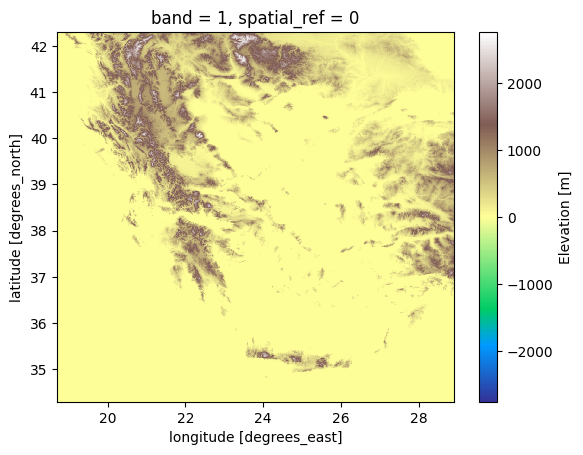

In [10]:
# 使用地形色谱绘制海拔 DEM表示海报高度
ds['DEM'].plot(cmap='terrain')

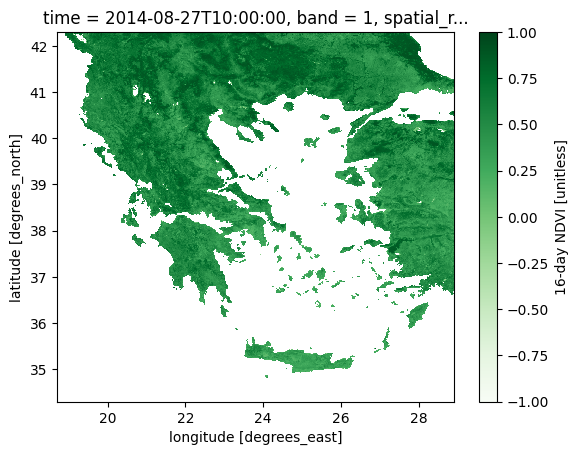

In [11]:
# 绿色越深代表植被越茂密
ds['ndvi'].isel(time=2000).plot(cmap='Greens')

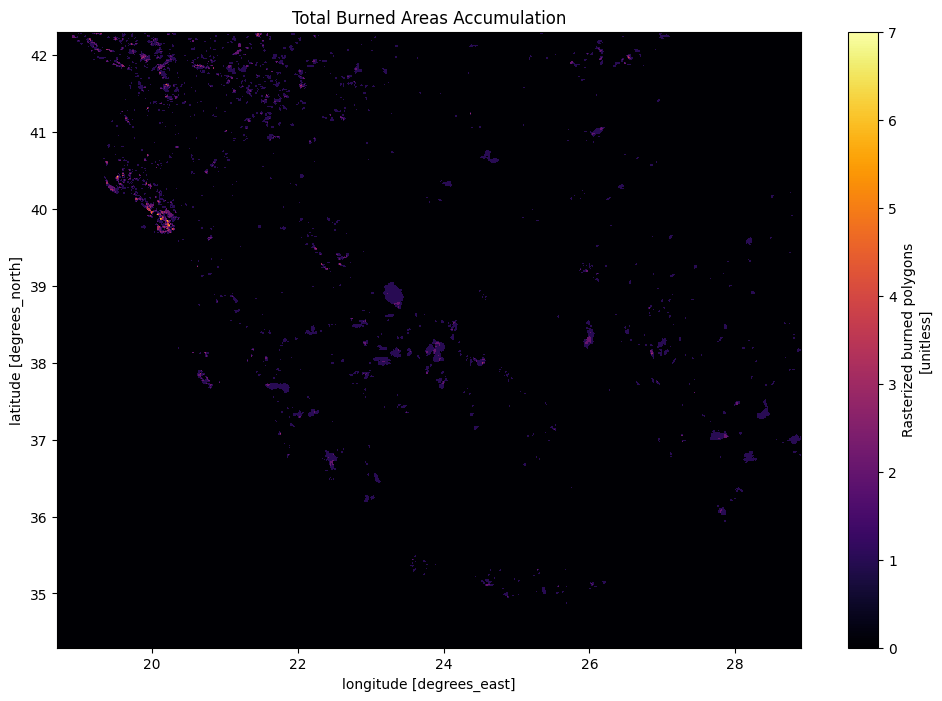

In [ ]:
plt.figure(figsize=(12, 8))
# 叠加所有时间的火灾区域
ds['burned_areas'].sum(dim='time').plot(cmap='inferno')
plt.title("Total Burned Areas Accumulation")
plt.show()

In [19]:
daily_burns = ds["burned_areas"].sum(dim=['x','y'])
worst_day_idx = daily_burns.argmax().item()

In [20]:
worst_day_idx

4532

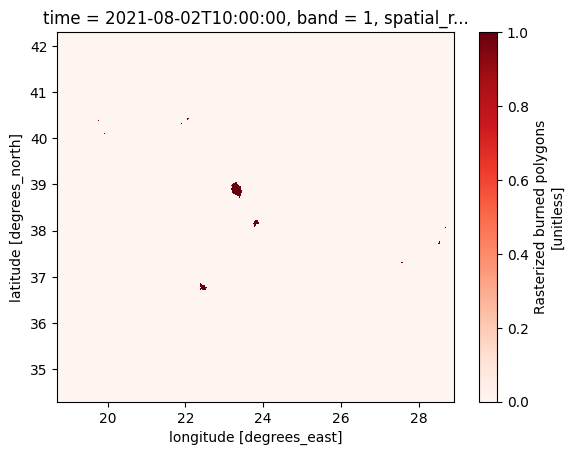

In [21]:
ds['burned_areas'].isel(time=4532).plot(cmap='Reds', vmin=0, vmax=1)

In [24]:
data_worst_day = ds['burned_areas'].isel(time=worst_day_idx)
burned_pixels = data_worst_day.sum().values
total_pixels = data_worst_day.size
percent = (burned_pixels / total_pixels) * 100
print(f"在火灾最严重的一天，燃烧面积占比仅为: {percent:.4f}%")

在火灾最严重的一天，燃烧面积占比仅为: 0.1150%


In [ ]:
# 切出2021年的一块像素的
mini_ds = ds.sel(time="2021").isel(x=slice(500,700),y=slice(400,600))
mini_ds.to_netcdf("mini_dataset.nc")

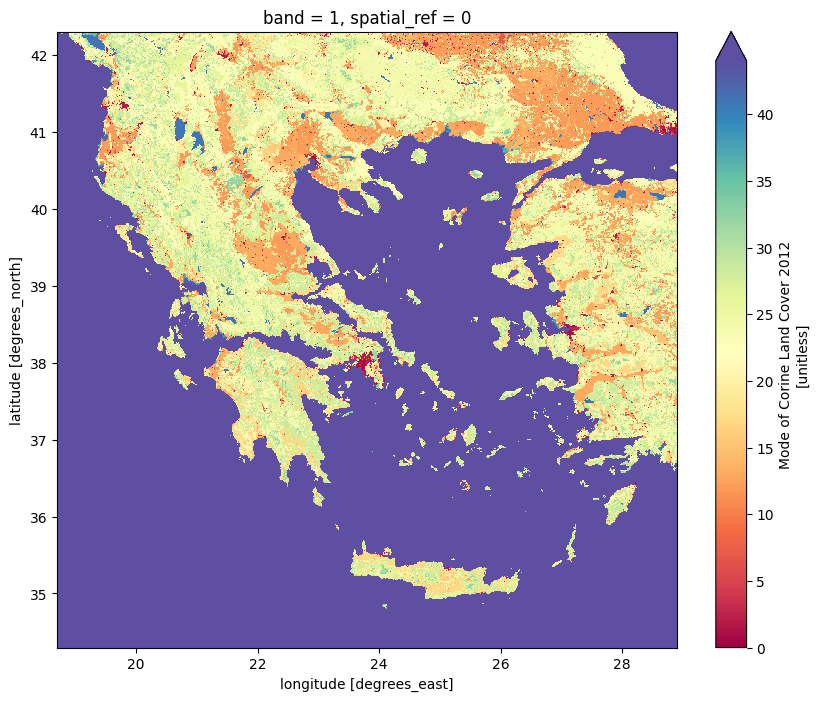

In [7]:
# 土地覆盖类型
ds['CLC_2012'].plot(cmap='Spectral', vmin=0, vmax=44, figsize=(10,8))

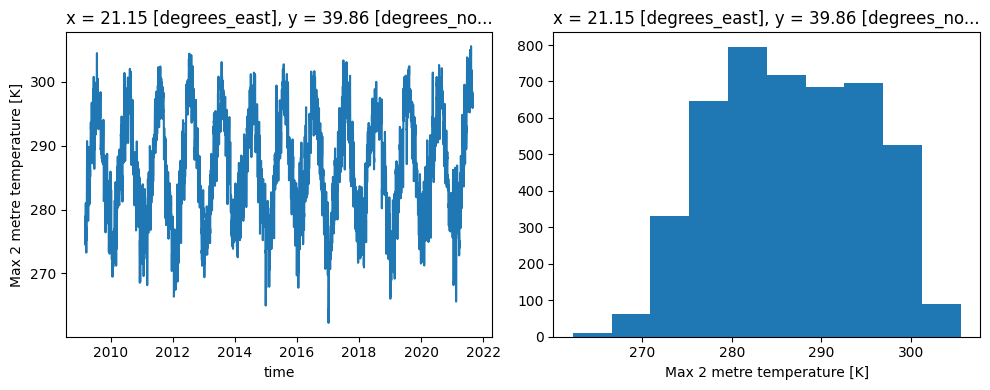

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(10,4))
(ds['max_t2m']).isel(x=300, y=300).plot(ax=axes[0]) #单点的时间序列的温度变化
(ds['max_t2m']).isel(x=300, y=300).plot.hist(ax=axes[1]) # 温度的分布情况
plt.tight_layout()
plt.draw()

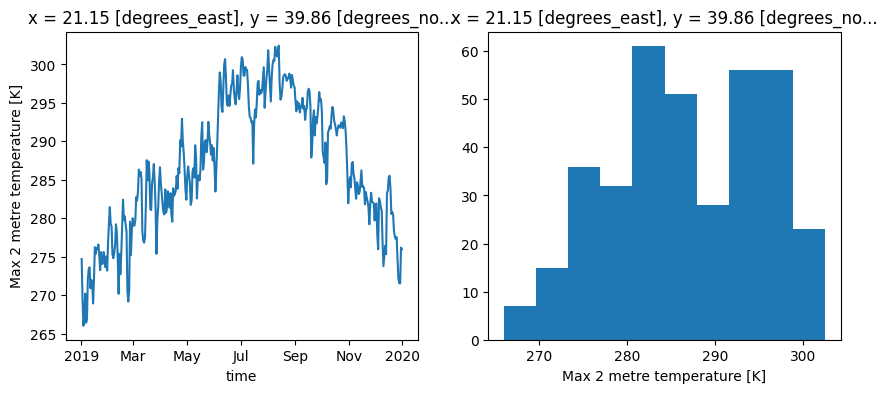

In [10]:
# 一年的分布情况
fig, axes = plt.subplots(ncols=2, figsize=(10,4))
ds['max_t2m'].sel(time=slice("2019-01-01", "2019-12-31")).isel(x=300, y=300).plot(ax=axes[0])
ds['max_t2m'].sel(time=slice("2019-01-01", "2019-12-31")).isel(x=300, y=300).plot.hist(ax=axes[1])
plt.show()

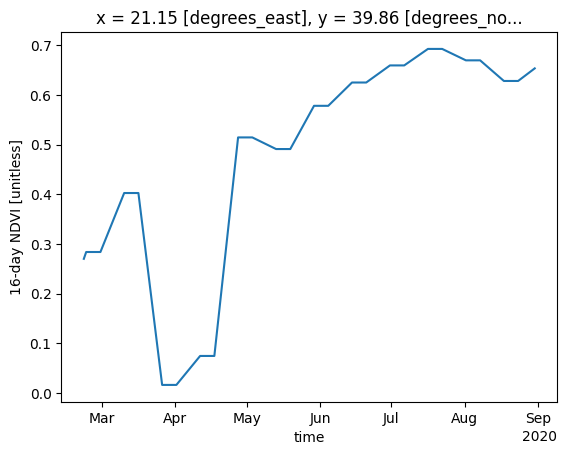

In [ ]:
# 某段时间范围内单点的植被指数变化
ds['ndvi'].isel(dict(time=slice(4000, 4200), x=300, y=300)).rolling(time=10, center=True).mean().plot()

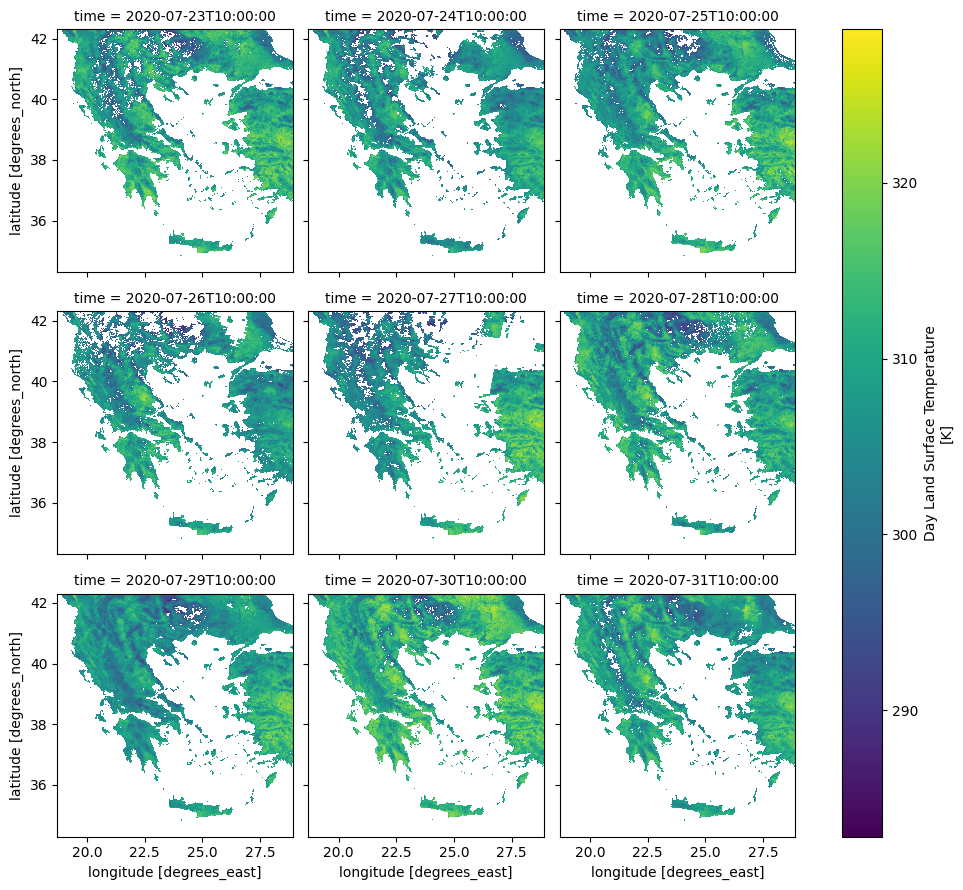

In [12]:
ds['lst_day'].isel(time=slice(4157, 4166)).plot(x="x", y="y", col="time", col_wrap=3)

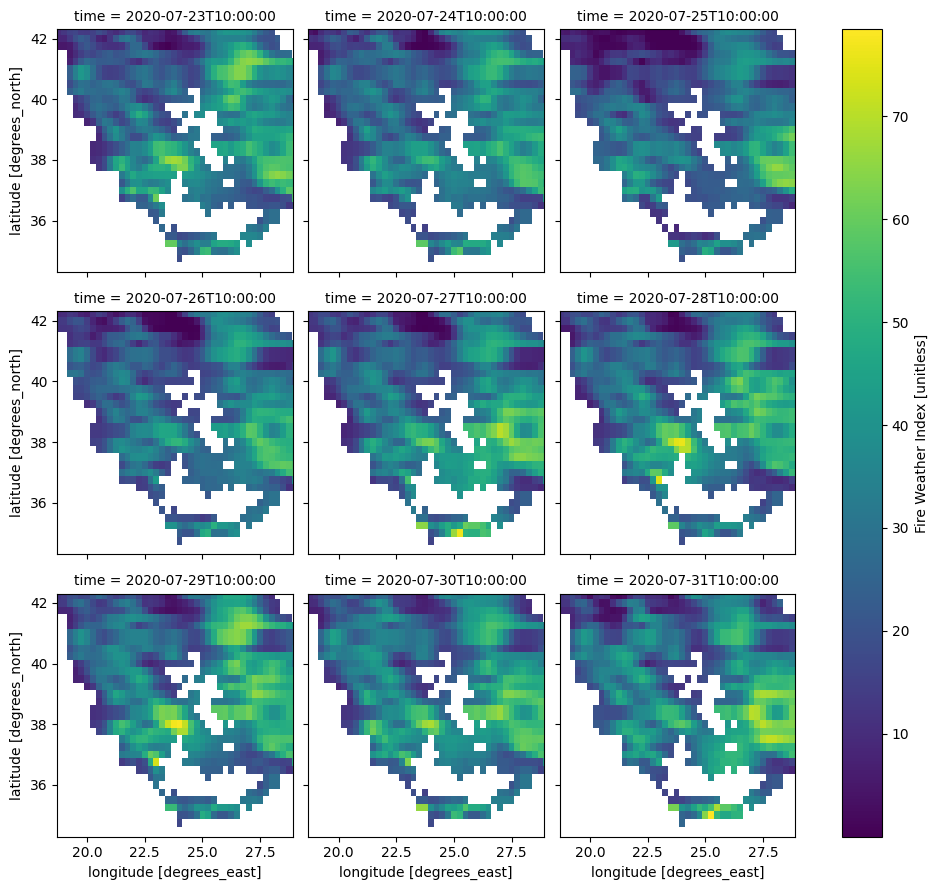

In [13]:
# 火险天气指数
ds['fwi'].isel(time=slice(4157, 4166)).plot(x="x", y="y", col="time", col_wrap=3)

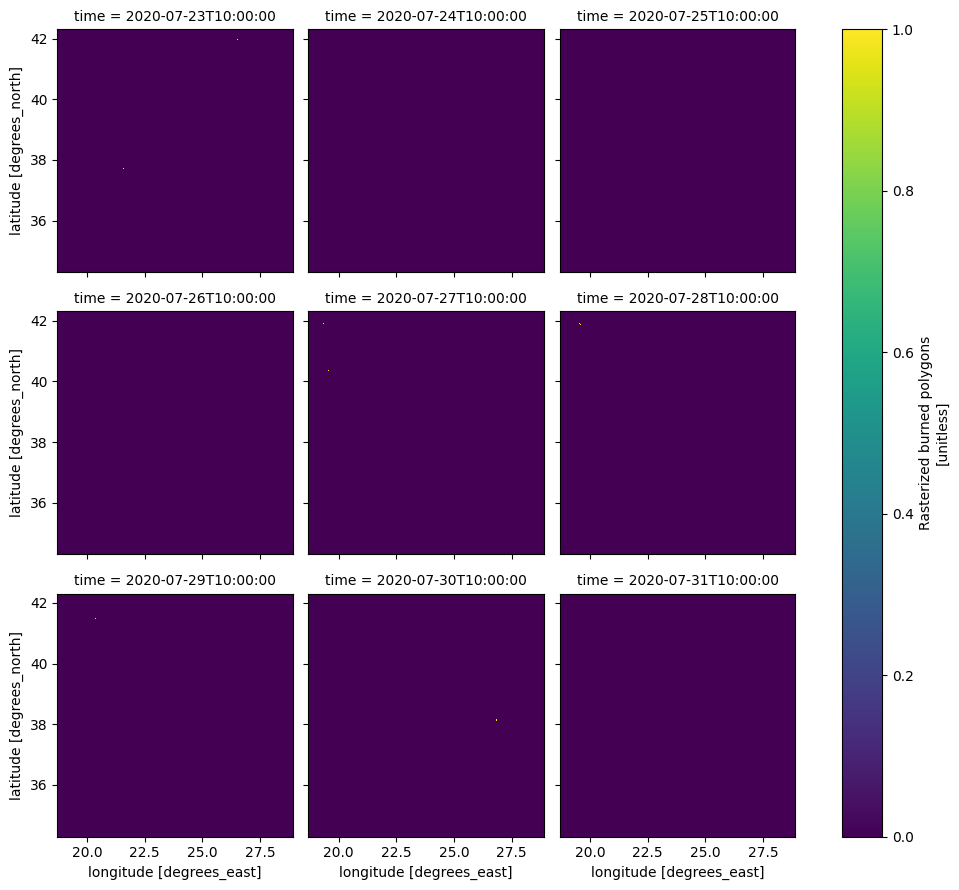

In [14]:
ds['burned_areas'].isel(time=slice(4157, 4166)).plot(x="x", y="y", col="time", col_wrap=3)

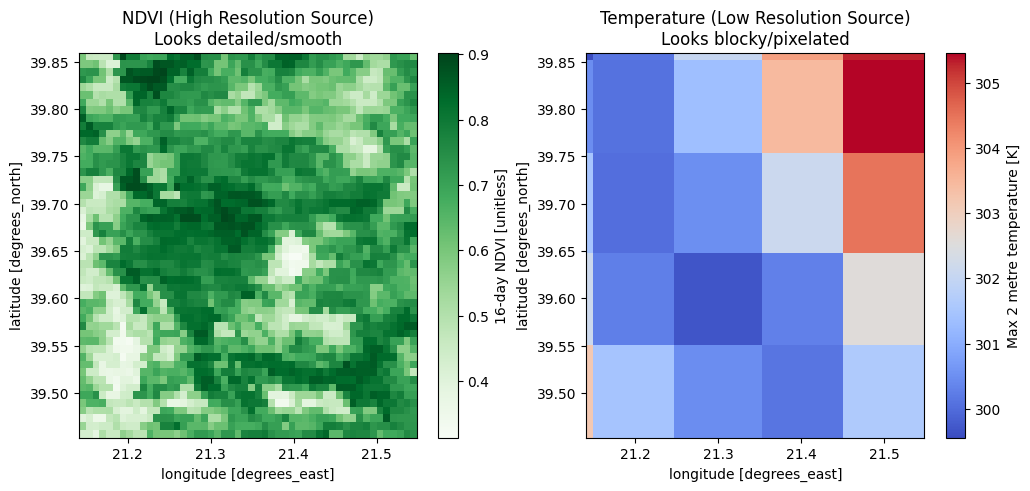

In [15]:
import matplotlib.pyplot as plt

# 我们只截取一小块区域 (50x50个格子)，这样能看清像素
# 如果是大图，你看不出马赛克
subset = ds.isel(time=2000, x=slice(300, 350), y=slice(300, 350))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. 画 NDVI (原生分辨率高)
subset['ndvi'].plot(ax=ax1, cmap='Greens')
ax1.set_title("NDVI (High Resolution Source)\nLooks detailed/smooth")

# 2. 画 max_t2m (原生分辨率低，比如 ERA5)
subset['max_t2m'].plot(ax=ax2, cmap='coolwarm')
ax2.set_title("Temperature (Low Resolution Source)\nLooks blocky/pixelated")

plt.show()

In [16]:
# 遍历打印每个变量的 source 或 title 属性
for var_name in ds.data_vars:
    # 获取该变量的属性字典
    attrs = ds[var_name].attrs
    # 尝试寻找也就是 source, title, long_name 这些字段
    print(f"=== {var_name} ===")
    print(f"Title: {attrs.get('title', 'N/A')}")
    print(f"Source/Long Name: {attrs.get('long_name', 'N/A')}")
    print("-" * 30)

=== burned_areas ===
Title: EFFIS (https://effis.jrc.ec.europa.eu/) burned areas burned as raster (value 1). Starting date retrieved with intersection with MODIS active fires
Source/Long Name: Rasterized burned polygons
------------------------------
=== ignition_points ===
Title: Ignition points burned as raster (value 1) on the map calculated from intersection of MODIS active fires and EFFIS (https://effis.jrc.ec.europa.eu/) burned areas
Source/Long Name: Rasterized ignition points
------------------------------
=== ndvi ===
Title: Normalized Difference Vegetation Index - MODIS/Terra Vegetation Indices 16-Day L3 Global 1 km SIN Grid
Source/Long Name: 16-day NDVI
------------------------------
=== number_of_fires ===
Title: Daily number of fires
Source/Long Name: Daily number of fires
------------------------------
=== evi ===
Title: Enhanced vegetation index - MODIS/Terra Vegetation Indices 16-Day L3 Global 1 km SIN Grid (MOD13A2)
Source/Long Name: 16-day EVI
------------------------

In [22]:
def check_effective_resolution(ds, var_name):
    # 1. 取一个时间切片 (去掉时间维度)
    # 2. 选取中间一行 (去掉 Y 维度，只看 X 轴的变化)
    # 注意：我们要用 .values 拿纯数字，且去掉 NaN (海洋)
    if var_name == "DEM":
        data_row = ds[var_name].isel(y=ds.sizes['y']//2).values
    else:
        data_row = ds[var_name].isel(time=0, y=ds.sizes['y']//2).values
    data_row = data_row[~np.isnan(data_row)] # 去掉 NaN
    
    if len(data_row) == 0:
        return "全是 NaN，无法检测"

    # 3. 计算相邻像素的差值 (后一个减前一个)
    diffs = np.diff(data_row)
    
    # 4. 统计有多少个差值是 0 (也就是数值没变)
    # 容忍度设一个小数值，防止浮点数误差
    zeros = np.sum(np.abs(diffs) < 1e-5)
    total = len(diffs)
    
    ratio = zeros / total
    print(f"变量 [{var_name}]: 重复像素比例 = {ratio:.2%}")
    
    if ratio > 0.8:
        print("   -> 结论：这是【低分辨率】数据 (呈阶梯状)")
    else:
        print("   -> 结论：这是【高分辨率】数据 (呈平滑状)")

# --- 运行测试 ---
print("正在检测各变量的分辨率特征...\n")
check_effective_resolution(ds, 'ndvi')      # 预期：重复率低
check_effective_resolution(ds, 'max_t2m')   # 预期：重复率高 (ERA5)
check_effective_resolution(ds, 'DEM')       # 预期：重复率低

正在检测各变量的分辨率特征...

变量 [ndvi]: 重复像素比例 = 23.86%
   -> 结论：这是【高分辨率】数据 (呈平滑状)
变量 [max_t2m]: 重复像素比例 = 94.37%
   -> 结论：这是【低分辨率】数据 (呈阶梯状)
变量 [DEM]: 重复像素比例 = 50.56%
   -> 结论：这是【高分辨率】数据 (呈平滑状)
